In [1]:
import pandas as pd
import polaris as po
import base64
import numpy as np

/home/hmacdope/mambaforge/envs/polaris_eval/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from rdkit import Chem

In [3]:
submissions = pd.read_json("./latest_competition_prediction.json")


In [4]:
def determine_subchallenge(data):
    sub = data["test"]
    if "Ligand Pose" in sub.keys():
        challenge = "Ligand Pose"
    elif "pIC50 (MERS-CoV Mpro)" and "pIC50 (SARS-CoV-2 Mpro)" in sub.keys():
        challenge = "Potency"
    elif "HLM" and "MLM" in sub.keys():
        challenge = "ADMET"
    else:
        raise ValueError()
    return challenge
        

In [5]:
submissions["subchallenge"] = submissions["predictions"].apply(determine_subchallenge)
submissions["predictions_unnested"] = submissions["predictions"].apply(lambda x: x["test"])

# Poses

In [6]:
poses_dataset = po.load_dataset("asap-discovery/antiviral-ligand-poses-2025-unblinded")
poses_data = pd.DataFrame(poses_dataset[:])

/home/hmacdope/mambaforge/envs/polaris_eval/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[2025-04-04 17:09:23] INFO     The version of Polaris that was used to create the artifact          ]8;id=992035;file:///home/hmacdope/mambaforge/envs/polaris_eval/lib/python3.12/site-packages/polaris/_artifact.py\_artifact.py]8;;\:]8;id=534051;file:///home/hmacdope/mambaforge/envs/polaris_eval/lib/python3.12/site-packages/polaris/_artifact.py#92\92]8;;\
                               (0.11.8.dev4+g40e3b2b.d20250207) is different from the currently                    
                               installed version of Polaris (0.11.10).                                             

                      WARNING  You're loading data from a remote location. If the dataset is small     ]8;id=392763;file:///home/hmacdope/mambaforge/envs/polaris_eval/lib/python3.12/site-packages/polaris/dataset/_base.py\_base.py]8;;\:]8;id=528453;file:///home/hmacdope/mambaforge/envs/polaris_eval/lib/python3.12/site-packages/polaris/dataset/_base.py#181\181]8;;\
                               enough, consider caching the dataset first using DatasetV2.cache() for              
                               more performant data access.                                                        

[17:09:24]  Success: Fetching dataset                                                                 ]8;id=685231;file:///home/hmacdope/mambaforge/envs/polaris_eval/lib/python3.12/site-packages/polaris/utils/context.py\context.py]8;;\:]8;id=684681;file:///home/hmacdope/mambaforge/envs/polaris_eval/lib/python3.12/site-packages/polaris/utils/context.py#53\53]8;;\

In [7]:
poses_test = poses_data.query("Set == 'Test'")

In [8]:
poses_test

,CXSMILES,Chain A Sequence,Chain B Sequence,Complex Structure,Ligand Pose,Protein Label,Protein Structure,Set
770,O=C1c2ccc(Cl)cc2[C@@]2(CN1Cc1nnco1)C(=O)N(c1cn...,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,None,<rdkit.Chem.rdchem.Mol object at 0x7f36d28b91c0>,MERS-CoV Mpro,None,Test
771,COc1ccc(N(Cc2cccc(Cl)c2)C(=O)Cc2cncc3ccccc23)cc1,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,None,<rdkit.Chem.rdchem.Mol object at 0x7f36d28b9170>,MERS-CoV Mpro,None,Test
772,CNC(=O)CN1C[C@@]2(C(=O)N(c3cncc4ccccc34)C[C@@H...,SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTS...,SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTS...,None,<rdkit.Chem.rdchem.Mol object at 0x7f36d28b9120>,SARS-CoV-2 Mpro,None,Test
773,CNC(=O)CN1C[C@@]2(C(=O)N(c3cncc4ccccc34)C[C@@H...,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,None,<rdkit.Chem.rdchem.Mol object at 0x7f36d28b8b30>,MERS-CoV Mpro,None,Test
774,O=C1c2ccc(Cl)cc2[C@@]2(CN1Cc1ccnnc1)C(=O)N(c1c...,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,None,<rdkit.Chem.rdchem.Mol object at 0x7f36d28b9080>,MERS-CoV Mpro,None,Test
...,...,...,...,...,...,...,...,...
960,CNS(=O)(=O)OCC(=O)N[C@@H](C)c1cc(Cl)cc(-c2ccc(...,SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTS...,SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTS...,None,<rdkit.Chem.rdchem.Mol object at 0x7f36d25c9a30>,SARS-CoV-2 Mpro,None,Test
961,CNC(=O)CN1C[C@@]2(C(=O)N(c3cncc4ccccc34)C[C@@H...,SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTS...,SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTS...,None,<rdkit.Chem.rdchem.Mol object at 0x7f36d25c9a80>,SARS-CoV-2 Mpro,None,Test
962,O=C(Cc1cncc2ccccc12)NCc1cccc(Cl)c1,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,SGLVKMSHPSGDVEACMVQVTCGSMTLNGLWLDNTVWCPRHVMCPA...,None,<rdkit.Chem.rdchem.Mol object at 0x7f36d25c9ad0>,MERS-CoV Mpro,None,Test
963,CNC(=O)CN1C[C@@]2(C(=O)N(c3cncc4ccccc34)C[C@@H...,SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTS...,SGFRKMAFPSGKVEGCMVQVTCGTTTLNGLWLDDVVYCPRHVICTS...,None,<rdkit.Chem.rdchem.Mol object at 0x7f36d25c9b20>,SARS-CoV-2 Mpro,None,Test


In [9]:
y_true = poses_test["Ligand Pose"]

In [10]:
y_true

770    <rdkit.Chem.rdchem.Mol object at 0x7f36d28b91c0>
771    <rdkit.Chem.rdchem.Mol object at 0x7f36d28b9170>
772    <rdkit.Chem.rdchem.Mol object at 0x7f36d28b9120>
773    <rdkit.Chem.rdchem.Mol object at 0x7f36d28b8b30>
774    <rdkit.Chem.rdchem.Mol object at 0x7f36d28b9080>
                             ...                       
960    <rdkit.Chem.rdchem.Mol object at 0x7f36d25c9a30>
961    <rdkit.Chem.rdchem.Mol object at 0x7f36d25c9a80>
962    <rdkit.Chem.rdchem.Mol object at 0x7f36d25c9ad0>
963    <rdkit.Chem.rdchem.Mol object at 0x7f36d25c9b20>
964    <rdkit.Chem.rdchem.Mol object at 0x7f36d25c9b70>
Name: Ligand Pose, Length: 195, dtype: object

In [11]:
from evaluation.ligand_poses import evaluate_all_ligand_pose_predictions

In [12]:
poses_submissions = submissions.query("subchallenge == 'Ligand Pose'")

In [13]:
for _, entry in poses_submissions.iterrows():
    print(entry["id"], entry["name"], "%%%", entry["description"], "%%%", entry["github_url"], "%%%", entry["report_url"], "\n")

competition-prediction-8oFF30AHg20eUKrnRQzUE asap-gnina-docking-baseline %%% Baseline docking for model comparison (both targets) %%% None %%% https://github.com/asapdiscovery/asap-polaris-challenge-baselines 

competition-prediction-Edd645cpFboFZRsUm20em protocol2 %%%  %%% None %%% https://docs.google.com/document/d/1QujhEKtMpdUwFxE_AVq6RBzsHEh4gjkd/edit?usp=sharing&ouid=102900202710669481806&rtpof=true&sd=true 

competition-prediction-tXLnHU72dFljtgWAuvh8Z openfe-newcastle-edinburgh-mcs-fegrow %%% FEGrow with mcs core structure finder. %%% https://github.com/jthorton/polaris_fegrow_mcs %%% https://github.com/jthorton/polaris_fegrow_mcs 

competition-prediction-late-im0HtqthslCqgR1BHgf9b asap-boltz-1-submission %%% Boltz aligned ligand poses %%% None %%% https://apricot-zorah-51.tiiny.site 

competition-prediction-sqr7BVpSxy4NSgljcEgl8 dodo-poses-submission %%% Submission generated using easydock pipeline with substructure alignment %%% https://github.com/fulopjoz/polaris-antiviral-su

In [14]:
entry_categories = {
    "competition-prediction-8oFF30AHg20eUKrnRQzUE": "CF",
    "competition-prediction-Edd645cpFboFZRsUm20em": "DL",
    "competition-prediction-tXLnHU72dFljtgWAuvh8Z": "PB",
    "competition-prediction-late-im0HtqthslCqgR1BHgf9b": "CF",
    "competition-prediction-sqr7BVpSxy4NSgljcEgl8": "PB",
    "competition-prediction-t4heZQ05hXlJ6vcfhZjP2": "PB",
    "competition-prediction-GL85gNve6u38L33Q2wUiJ": "DL",
    "competition-prediction-Kec3G0H9KJGWfRouaHDLQ": "PB",
    "competition-prediction-JPiM6etVV4SNygnvAZqj7": "CF",
    "competition-prediction-M0ePYflVVxiF79RnRcCkC": "PB",
    "competition-prediction-S9yhyrYVraSy6vZ3u0iwS": "DL",
    "competition-prediction-pxXgSbG31dfMbqohnMnfP": "CF",
    "competition-prediction-DLGeSzUxB29MqK9pnBawM": "PB",
    "competition-prediction-8ygjELYPeCo3or8AS6Xom": "DL",
    "competition-prediction-o8n3Fgdevuj8th3FfUNu1": "DL",
    "competition-prediction-TPDYWfhEw4nYp81Kd5s1W": "PB",
    "competition-prediction-th7lSmtpv1tMxmNjYqCJU": "PB",
    "competition-prediction-kMD7A97Q9b7wnRH8Ze9e": "PB",
    "competition-prediction-TSWQyQgwNyUbdp5EaGbmU": "PB",
    "competition-prediction-SXMdEmccFmbNBtiVCZvp9": "CF",
    "competition-prediction-JLy17Fu87yM2ch741quDp": "PB",
    "competition-prediction-MoEWcKkwYkPeFHrw3qaWd": "PB",
    "competition-prediction-sKvyY8FZzDDX1jaFpBG8t": "CF",
    "competition-prediction-GZRD1499Q0k3ejSX7wR22": "PB",
    'competition-prediction-kMD7A97Q9b7wnRH8Ze9e9': "PB",
}

In [15]:
BASELINE_ID = "competition-prediction-DLGeSzUxB29MqK9pnBawM"

In [16]:
poses_compact = poses_submissions[["id","predictions_unnested"]].set_index("id")

In [17]:
poses_compact

,predictions_unnested
id,
competition-prediction-8oFF30AHg20eUKrnRQzUE,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-Edd645cpFboFZRsUm20em,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-tXLnHU72dFljtgWAuvh8Z,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-late-im0HtqthslCqgR1BHgf9b,{'Ligand Pose': ['776t3gAAAAAQAAAAAQAAAAAAAAAp...
competition-prediction-sqr7BVpSxy4NSgljcEgl8,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-t4heZQ05hXlJ6vcfhZjP2,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAA/...
competition-prediction-GL85gNve6u38L33Q2wUiJ,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...
competition-prediction-Kec3G0H9KJGWfRouaHDLQ,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAA/...
competition-prediction-JPiM6etVV4SNygnvAZqj7,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...


In [18]:
def deserialize_rdkit_mol(b64_string: str) -> Chem.Mol:
    mol_bytes = base64.b64decode(b64_string)
    return Chem.Mol(mol_bytes)

In [19]:
def serialized_list_to_rdkit(data: list[str]) -> list[Chem.Mol]:
    mols = []
    for d in data:
        mols.append(deserialize_rdkit_mol(d))
    return mols

In [20]:
poses_compact["predictions_rdkit_mols"] = poses_compact["predictions_unnested"].apply(lambda x: serialized_list_to_rdkit(x["Ligand Pose"]))

In [21]:
poses_compact

,predictions_unnested,predictions_rdkit_mols
id,,
competition-prediction-8oFF30AHg20eUKrnRQzUE,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x7f36d8dc44...
competition-prediction-Edd645cpFboFZRsUm20em,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x7f36d8d9c3...
competition-prediction-tXLnHU72dFljtgWAuvh8Z,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x7f36d8d9ff...
competition-prediction-late-im0HtqthslCqgR1BHgf9b,{'Ligand Pose': ['776t3gAAAAAQAAAAAQAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x7f36d8d9bc...
competition-prediction-sqr7BVpSxy4NSgljcEgl8,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x7f36d8ddf9...
competition-prediction-t4heZQ05hXlJ6vcfhZjP2,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAA/...,[<rdkit.Chem.rdchem.Mol object at 0x7f36d8ddb6...
competition-prediction-GL85gNve6u38L33Q2wUiJ,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x7f36d27233...
competition-prediction-Kec3G0H9KJGWfRouaHDLQ,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAA/...,[<rdkit.Chem.rdchem.Mol object at 0x7f36d27371...
competition-prediction-JPiM6etVV4SNygnvAZqj7,{'Ligand Pose': ['776t3gAAAAAQAAAAAgAAAAAAAAAp...,[<rdkit.Chem.rdchem.Mol object at 0x7f36d275ee...


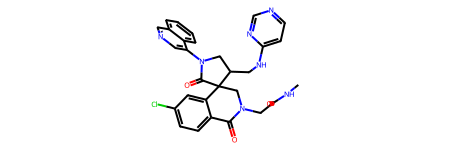

In [22]:
poses_compact["predictions_rdkit_mols"].iloc[0][2]

In [23]:
poses_compact_dict = poses_compact.to_dict()["predictions_rdkit_mols"]

In [24]:
poses_compact_dict

{'competition-prediction-8oFF30AHg20eUKrnRQzUE': [<rdkit.Chem.rdchem.Mol at 0x7f36d8dc4450>,
 'competition-prediction-Edd645cpFboFZRsUm20em': [<rdkit.Chem.rdchem.Mol at 0x7f36d8d9c360>,
 'competition-prediction-tXLnHU72dFljtgWAuvh8Z': [<rdkit.Chem.rdchem.Mol at 0x7f36d8d9ff10>,
 'competition-prediction-late-im0HtqthslCqgR1BHgf9b': [<rdkit.Chem.rdchem.Mol at 0x7f36d8d9bc40>,
 'competition-prediction-sqr7BVpSxy4NSgljcEgl8': [<rdkit.Chem.rdchem.Mol at 0x7f36d8ddf970>,
 'competition-prediction-t4heZQ05hXlJ6vcfhZjP2': [<rdkit.Chem.rdchem.Mol at 0x7f36d8ddb6a0>,
 'competition-prediction-GL85gNve6u38L33Q2wUiJ': [<rdkit.Chem.rdchem.Mol at 0x7f36d27233d0>,
 'competition-prediction-Kec3G0H9KJGWfRouaHDLQ': [<rdkit.Chem.rdchem.Mol at 0x7f36d2737100>,
 'competition-prediction-JPiM6etVV4SNygnvAZqj7': [<rdkit.Chem.rdchem.Mol at 0x7f36d275ee30>,
 'competition-prediction-M0ePYflVVxiF79RnRcCkC': [<rdkit.Chem.rdchem.Mol at 0x7f36d2702b60>,
 'competition-prediction-S9yhyrYVraSy6vZ3u0iwS': [<rdkit.Chem.rdc

In [25]:
main, leaderboards = evaluate_all_ligand_pose_predictions(y_true, poses_compact_dict)

Found 275 significantly different pairs


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 275/275 [00:00<00:00, 55172.37it/s]


In [26]:
main

,Method,CLD,mean_rmsd,mean_rmsd_raw,mean_rmsd_std,success_rate,success_rate_raw,success_rate_std
18,competition-prediction-pxXgSbG31dfMbqohnMnfP,a,1.330 ± 0.266,1.329511,0.266044,86.378 ± 2.466,86.377596,2.466433
19,competition-prediction-sKvyY8FZzDDX1jaFpBG8t,b,1.368 ± 0.265,1.367916,0.264880,85.363 ± 2.603,85.362842,2.603348
12,competition-prediction-SXMdEmccFmbNBtiVCZvp9,b,1.388 ± 0.267,1.387794,0.266933,85.213 ± 2.601,85.213115,2.601177
3,competition-prediction-Edd645cpFboFZRsUm20em,c,1.432 ± 0.266,1.431575,0.266270,84.673 ± 2.670,84.673224,2.670313
16,competition-prediction-late-im0HtqthslCqgR1BHgf9b,d,1.549 ± 0.269,1.548972,0.269090,83.657 ± 2.769,83.657377,2.769367
7,competition-prediction-JPiM6etVV4SNygnvAZqj7,e,5.045 ± 0.906,5.044790,0.905610,73.283 ± 3.368,73.283060,3.368103
2,competition-prediction-DLGeSzUxB29MqK9pnBawM,f,2.214 ± 0.287,2.214030,0.287115,67.277 ± 3.453,67.277049,3.453156
13,competition-prediction-TPDYWfhEw4nYp81Kd5s1W,g,2.334 ± 0.276,2.334483,0.276487,62.475 ± 3.583,62.475410,3.583471
21,competition-prediction-t4heZQ05hXlJ6vcfhZjP2,h,2.647 ± 0.286,2.646826,0.286095,53.138 ± 3.686,53.138251,3.685566
22,competition-prediction-tXLnHU72dFljtgWAuvh8Z,i,5.046 ± 0.774,5.045802,0.774471,48.136 ± 3.703,48.136066,3.703007


In [27]:
main

,Method,CLD,mean_rmsd,mean_rmsd_raw,mean_rmsd_std,success_rate,success_rate_raw,success_rate_std
18,competition-prediction-pxXgSbG31dfMbqohnMnfP,a,1.330 ± 0.266,1.329511,0.266044,86.378 ± 2.466,86.377596,2.466433
19,competition-prediction-sKvyY8FZzDDX1jaFpBG8t,b,1.368 ± 0.265,1.367916,0.264880,85.363 ± 2.603,85.362842,2.603348
12,competition-prediction-SXMdEmccFmbNBtiVCZvp9,b,1.388 ± 0.267,1.387794,0.266933,85.213 ± 2.601,85.213115,2.601177
3,competition-prediction-Edd645cpFboFZRsUm20em,c,1.432 ± 0.266,1.431575,0.266270,84.673 ± 2.670,84.673224,2.670313
16,competition-prediction-late-im0HtqthslCqgR1BHgf9b,d,1.549 ± 0.269,1.548972,0.269090,83.657 ± 2.769,83.657377,2.769367
7,competition-prediction-JPiM6etVV4SNygnvAZqj7,e,5.045 ± 0.906,5.044790,0.905610,73.283 ± 3.368,73.283060,3.368103
2,competition-prediction-DLGeSzUxB29MqK9pnBawM,f,2.214 ± 0.287,2.214030,0.287115,67.277 ± 3.453,67.277049,3.453156
13,competition-prediction-TPDYWfhEw4nYp81Kd5s1W,g,2.334 ± 0.276,2.334483,0.276487,62.475 ± 3.583,62.475410,3.583471
21,competition-prediction-t4heZQ05hXlJ6vcfhZjP2,h,2.647 ± 0.286,2.646826,0.286095,53.138 ± 3.686,53.138251,3.685566
22,competition-prediction-tXLnHU72dFljtgWAuvh8Z,i,5.046 ± 0.774,5.045802,0.774471,48.136 ± 3.703,48.136066,3.703007


In [28]:
def assign_colour(leaderboard, CLD_col, baseline_id):
    # get where it is A
    a_mask = leaderboard[CLD_col] == 'a'
    a_in_mask = leaderboard[CLD_col].str.contains(r'\b\w*a\w*\b', case=True, na=False)

    # default is worse
    leaderboard["colour"] = 'tab:grey'
    # equivalent, do first
    leaderboard["colour"][a_in_mask] = 'tab:orange'

    # the baseline TODO
    baseline_mask = leaderboard["Method"] == baseline_id
    leaderboard["colour"][baseline_mask] = 'tab:green'
    
    # the best
    leaderboard["colour"][a_mask] = 'tab:blue'
    

    return leaderboard


In [29]:
main =  assign_colour(main, "CLD", BASELINE_ID)


/tmp/ipykernel_942223/2086293688.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  leaderboard["colour"] = 'tab:grey'
/tmp/ipykernel_942223/2086293688.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in

In [30]:
main

,Method,CLD,mean_rmsd,mean_rmsd_raw,mean_rmsd_std,success_rate,success_rate_raw,success_rate_std,colour
18,competition-prediction-pxXgSbG31dfMbqohnMnfP,a,1.330 ± 0.266,1.329511,0.266044,86.378 ± 2.466,86.377596,2.466433,tab:blue
19,competition-prediction-sKvyY8FZzDDX1jaFpBG8t,b,1.368 ± 0.265,1.367916,0.264880,85.363 ± 2.603,85.362842,2.603348,tab:grey
12,competition-prediction-SXMdEmccFmbNBtiVCZvp9,b,1.388 ± 0.267,1.387794,0.266933,85.213 ± 2.601,85.213115,2.601177,tab:grey
3,competition-prediction-Edd645cpFboFZRsUm20em,c,1.432 ± 0.266,1.431575,0.266270,84.673 ± 2.670,84.673224,2.670313,tab:grey
16,competition-prediction-late-im0HtqthslCqgR1BHgf9b,d,1.549 ± 0.269,1.548972,0.269090,83.657 ± 2.769,83.657377,2.769367,tab:grey
7,competition-prediction-JPiM6etVV4SNygnvAZqj7,e,5.045 ± 0.906,5.044790,0.905610,73.283 ± 3.368,73.283060,3.368103,tab:grey
2,competition-prediction-DLGeSzUxB29MqK9pnBawM,f,2.214 ± 0.287,2.214030,0.287115,67.277 ± 3.453,67.277049,3.453156,tab:green
13,competition-prediction-TPDYWfhEw4nYp81Kd5s1W,g,2.334 ± 0.276,2.334483,0.276487,62.475 ± 3.583,62.475410,3.583471,tab:grey
21,competition-prediction-t4heZQ05hXlJ6vcfhZjP2,h,2.647 ± 0.286,2.646826,0.286095,53.138 ± 3.686,53.138251,3.685566,tab:grey
22,competition-prediction-tXLnHU72dFljtgWAuvh8Z,i,5.046 ± 0.774,5.045802,0.774471,48.136 ± 3.703,48.136066,3.703007,tab:grey


In [31]:
from matplotlib import pyplot as plt

In [37]:
def make_plot(agg, metric, metric_label, ascending, entry_categories, xlim):


    f, axes = plt.subplots(1, 1, figsize=(12, 9), sharex=True, sharey=False, constrained_layout=True)
    
    # sars
    sars_tick_positions = []
    sars_tick_labels = []
    for i,  (_, entry) in enumerate(agg.iterrows()):
        axes.scatter(entry[metric + "_raw"], i, s=12, color=entry["colour"])
        axes.errorbar(entry[metric + "_raw"], i, xerr=entry[metric + "_std"], ls="none", color=entry["colour"])
        axes.set_title("Poses")
    
        # add in CLD
        axes.annotate(entry["CLD"],  xy=(entry[metric + "_raw"] + entry[metric + "_std"], i-0.25), size=9)

        # add in the methodology
        sars_tick_positions.append(i)
        sars_tick_labels.append(entry_categories[entry["Method"]])

    axes.set_yticks(sars_tick_positions, sars_tick_labels)
    axes.set_ylim(-1, 24)
    axes.set_xlim(xlim)
    axes.set_xticks(np.arange(xlim[0], xlim[1], 10))
    axes.set_xlabel(metric_label)

    
    axes.yaxis.grid(True)

    axes.invert_yaxis()

    axes.set_ylabel("Challenge entries")
    
    axes.legend(handles=[ # make a custom legend
        patches.Patch(color='tab:blue', label='Top'),
        patches.Patch(color='tab:orange', label='Equal'),
        patches.Patch(color='tab:gray', label='Lower'),
        patches.Patch(color='tab:green', label='Baseline'),

    ], framealpha=1, bbox_to_anchor=(1.4, 1.05))
    
    plt.savefig(f"Leaderboard_plot_poses_{metric}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [38]:
entry_categories

{'competition-prediction-8oFF30AHg20eUKrnRQzUE': 'CF',
 'competition-prediction-Edd645cpFboFZRsUm20em': 'DL',
 'competition-prediction-tXLnHU72dFljtgWAuvh8Z': 'PB',
 'competition-prediction-late-im0HtqthslCqgR1BHgf9b': 'CF',
 'competition-prediction-sqr7BVpSxy4NSgljcEgl8': 'PB',
 'competition-prediction-t4heZQ05hXlJ6vcfhZjP2': 'PB',
 'competition-prediction-GL85gNve6u38L33Q2wUiJ': 'DL',
 'competition-prediction-Kec3G0H9KJGWfRouaHDLQ': 'PB',
 'competition-prediction-JPiM6etVV4SNygnvAZqj7': 'CF',
 'competition-prediction-M0ePYflVVxiF79RnRcCkC': 'PB',
 'competition-prediction-S9yhyrYVraSy6vZ3u0iwS': 'DL',
 'competition-prediction-pxXgSbG31dfMbqohnMnfP': 'CF',
 'competition-prediction-DLGeSzUxB29MqK9pnBawM': 'PB',
 'competition-prediction-8ygjELYPeCo3or8AS6Xom': 'DL',
 'competition-prediction-o8n3Fgdevuj8th3FfUNu1': 'DL',
 'competition-prediction-TPDYWfhEw4nYp81Kd5s1W': 'PB',
 'competition-prediction-th7lSmtpv1tMxmNjYqCJU': 'PB',
 'competition-prediction-kMD7A97Q9b7wnRH8Ze9e': 'PB',
 'comp

In [39]:
len(entry_categories)

25

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


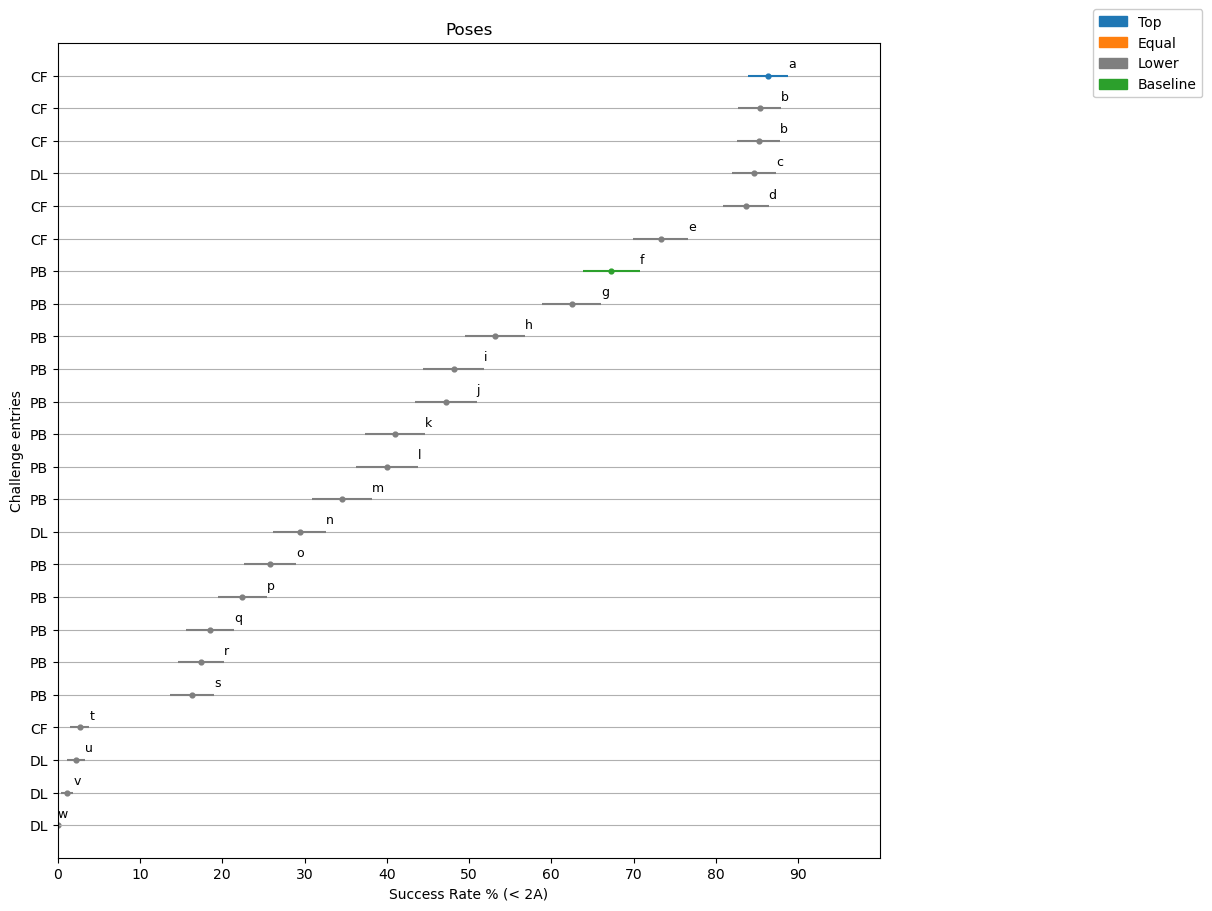

In [42]:
make_plot(main, "success_rate", "Success Rate % (< 2A)", BASELINE_ID, entry_categories, (0, 100))